# **Practical Task-1:**

In [1]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
import re
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("10. tripadvisor_hotel_reviews.csv")
data.info()
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  109 non-null    object
 1   Rating  109 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


,Review,Rating
0,Nice hotel expensive parking got good deal sta...,4
1,Ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"Unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5
5,love monaco staff husband stayed hotel crazy w...,5
6,"cozy stay rainy city, husband spent 7 nights m...",5
7,"excellent staff, housekeeping quality hotel ch...",4
8,"hotel stayed hotel monaco cruise, rooms genero...",5
9,excellent stayed hotel monaco past w/e delight...,5


In [3]:
print(data["Review"][0])

Nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  


In [4]:
data['review_lower'] = data['Review'].str.lower()

In [5]:
data.head()

,Review,Rating,review_lower
0,Nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,Ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...
3,"Unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso..."


In [6]:
en_stopwords = stopwords.words('english')
data['review_lower_noStopWords'] = data['review_lower'].apply(lambda x :' '.join([word for word in x.split() if word not in en_stopwords]))
data.head()

,Review,Rating,review_lower,review_lower_noStopWords
0,Nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,Ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...
3,"Unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso..."


In [7]:
data['no_noPunc'] = data.apply(lambda x : re.sub(r"[*]",'star',x['review_lower_noStopWords']),axis =1)
data.head()

,Review,Rating,review_lower,review_lower_noStopWords,no_noPunc
0,Nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,Ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...
3,"Unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso..."


In [8]:
data['no_noPunc'] = data.apply(lambda x : re.sub(r"[^\w\s]",'star',x['review_lower_noStopWords']),axis =1)
data.head()

,Review,Rating,review_lower,review_lower_noStopWords,no_noPunc
0,Nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,Ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...
3,"Unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",uniquestar great staystar wonderful time hotel...
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great staystar went seahawk game aw...


In [9]:
data['word_tokens'] = data.apply(lambda x: word_tokenize(x['no_noPunc']),axis=1)
data.head()

,Review,Rating,review_lower,review_lower_noStopWords,no_noPunc,word_tokens
0,Nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d..."
1,Ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...,"[nice, rooms, 4star, experience, hotel, monaco..."
3,"Unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",uniquestar great staystar wonderful time hotel...,"[uniquestar, great, staystar, wonderful, time,..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great staystar went seahawk game aw...,"[great, stay, great, staystar, went, seahawk, ..."


In [10]:
ps = PorterStemmer()
data['word_tokens_stemmetized'] = data['word_tokens'].apply(lambda x: [ps.stem(word) for word in x])
data.head()

,Review,Rating,review_lower,review_lower_noStopWords,no_noPunc,word_tokens,word_tokens_stemmetized
0,Nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s..."
1,Ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...,"[nice, rooms, 4star, experience, hotel, monaco...","[nice, room, 4star, experi, hotel, monaco, sea..."
3,"Unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",uniquestar great staystar wonderful time hotel...,"[uniquestar, great, staystar, wonderful, time,...","[uniquestar, great, staystar, wonder, time, ho..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great staystar went seahawk game aw...,"[great, stay, great, staystar, went, seahawk, ...","[great, stay, great, staystar, went, seahawk, ..."


In [11]:
lemmatizer = WordNetLemmatizer()
data['lemmatized'] = data['word_tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
data.head()

,Review,Rating,review_lower,review_lower_noStopWords,no_noPunc,word_tokens,word_tokens_stemmetized,lemmatized
0,Nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s...","[nice, hotel, expensive, parking, got, good, d..."
1,Ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi...","[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...,"[nice, rooms, 4star, experience, hotel, monaco...","[nice, room, 4star, experi, hotel, monaco, sea...","[nice, room, 4star, experience, hotel, monaco,..."
3,"Unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",uniquestar great staystar wonderful time hotel...,"[uniquestar, great, staystar, wonderful, time,...","[uniquestar, great, staystar, wonder, time, ho...","[uniquestar, great, staystar, wonderful, time,..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great staystar went seahawk game aw...,"[great, stay, great, staystar, went, seahawk, ...","[great, stay, great, staystar, went, seahawk, ...","[great, stay, great, staystar, went, seahawk, ..."


In [12]:
data['lemmatized'][0]

['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversarystar',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'review',
 'valet',
 'parkingstar',
 'check',
 'quick',
 'easystar',
 'little',
 'disappointed',
 'nonstarexistent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'sizestar',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillowsstar',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bang',
 'door',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallwaystar',
 'maybe',
 'noisy',
 'neighborsstar',
 'aveda',
 'bath',
 'product',
 'nicestar',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longerstar',
 'location',
 'great',
 'walking',
 'distance',
 'shoppingstar',
 'overall',
 'nice',
 'experience',
 'pay',
 '40',
 'parking',
 'nightstar']

In [13]:
tokens_clean = sum(data['lemmatized'],[])
tokens_clean

['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversarystar',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'review',
 'valet',
 'parkingstar',
 'check',
 'quick',
 'easystar',
 'little',
 'disappointed',
 'nonstarexistent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'sizestar',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillowsstar',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bang',
 'door',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallwaystar',
 'maybe',
 'noisy',
 'neighborsstar',
 'aveda',
 'bath',
 'product',
 'nicestar',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longerstar',
 'location',
 'great',
 'walking',
 'distance',
 'shoppingstar',
 'overall',
 'nice',
 'experience',
 'pay',
 '40',
 'parking',
 'nightstar',
 'ok',
 'nothing',
 'special',
 'charge',
 'diamond',
 'member',
 'hilton',
 'de

In [14]:
unigrams =pd.Series(nltk.ngrams(tokens_clean,1)).value_counts()
unigrams[:10]


(hotel,)       251
(room,)        238
(great,)       116
(staff,)        85
(nstart,)       78
(stay,)         69
(location,)     69
(good,)         68
(nice,)         65
(seattle,)      61
Name: count, dtype: int64

<Axes: >

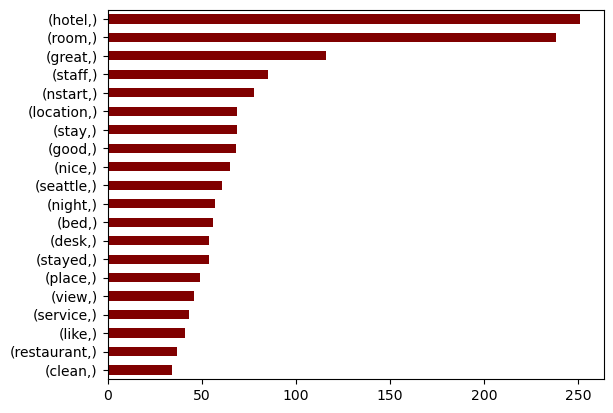

In [15]:
unigrams[:20].sort_values().plot.barh(color='maroon')

In [16]:
bigrams =pd.Series(nltk.ngrams(tokens_clean,2)).value_counts()
bigrams[:10]


(great, location)    21
(space, needle)      18
(hotel, monaco)      14
(pike, place)        12
(staff, friendly)    10
(location, great)     9
(great, view)         9
(great, hotel)        9
(hotel, great)        8
(desk, clerk)         8
Name: count, dtype: int64

<Axes: >

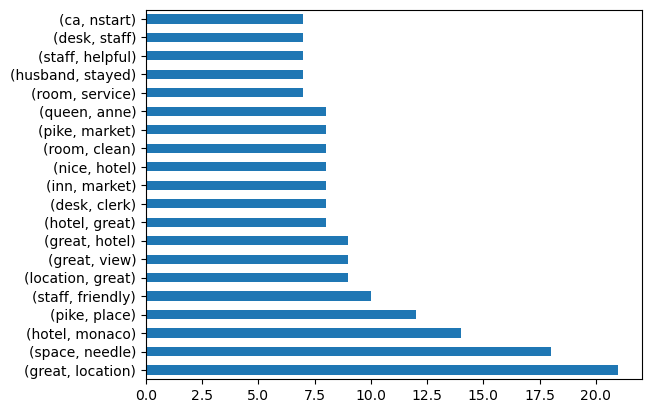

In [17]:
bigrams[:20].plot.barh()

In [18]:
trigrams =pd.Series(nltk.ngrams(tokens_clean,3)).value_counts()
trigrams[:10]


(view, space, needle)             4
(hotel, great, location)          4
(pike, place, marketstar)         4
(pike, place, market)             4
(stayed, inn, market)             4
(inn, queen, anne)                4
(hotel, husband, stayed)          3
(staff, friendly, helpfulstar)    3
(room, king, bed)                 3
(experience, music, project)      3
Name: count, dtype: int64

<Axes: >

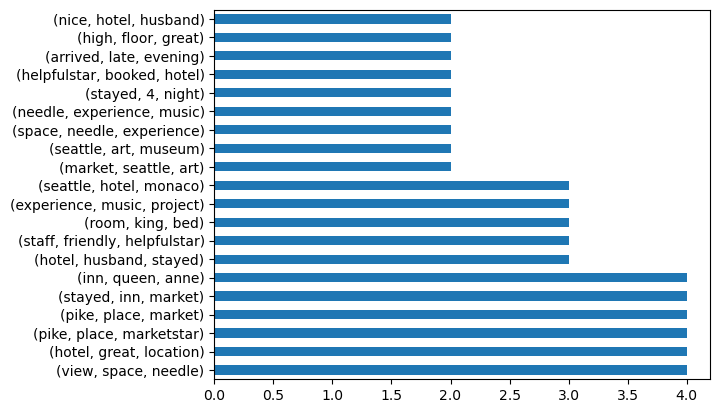

In [19]:
trigrams[:20].plot.barh()